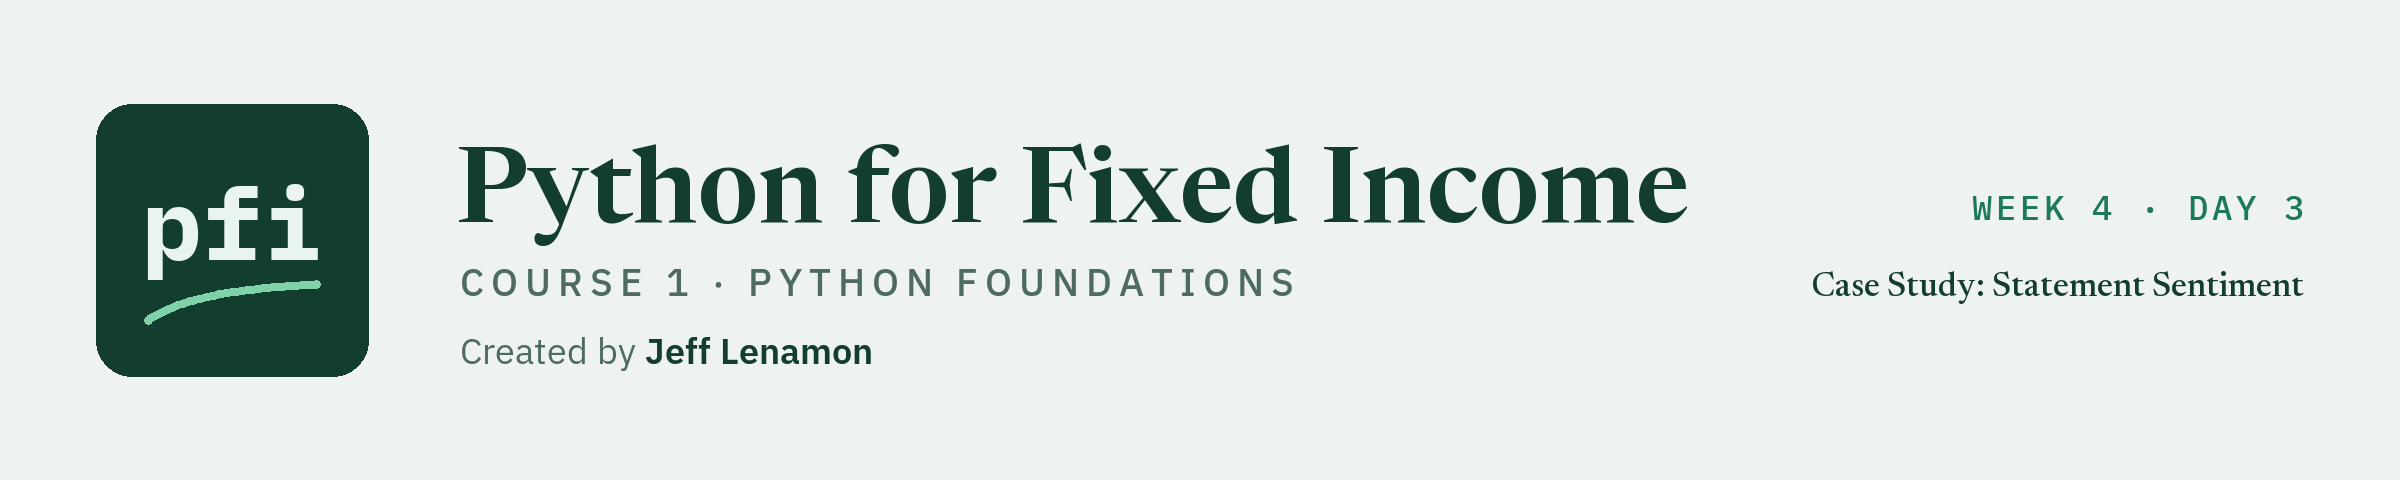

# Case Study: Statement Sentiment

Week 4. The wording of 46 published statements is turned into a number three ways, the three numbers are compared with each other and with Treasury yields, and the limits of each are written down.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day3/18_case_study_statement_sentiment.ipynb)

## Problem Definition

### Context

The desk reads every statement of the Federal Open Market Committee on the day it is published. Yesterday's notebook counted the words in those statements. Today the head of the desk asks the next question: **can the wording of a statement be turned into one number, statement by statement, and how far can such a number be trusted?**

### Objective

You are the desk's analyst. The method is called **lexicon-based sentiment scoring**. A **lexicon** is a list of words, each marked as positive or negative, or given a rating. A score is a count: the listed words found in a text, added up.

That is all a score is, and this notebook holds to it. A score is a property of the wording, measured by a stated word list. It is reported as "the list scores the statement of a date at a number". It does not say what the authors of a text meant, it does not say what happens next, and it is not a reason to do anything. The lesson is as much about where the method fails as about the method.

### The data

Two files, both real and public. There is no portfolio data in this notebook.

**The statements**, the file used in notebook 17.

* Source: Board of Governors of the Federal Reserve System, Federal Open Market Committee statements, federalreserve.gov. Each statement was downloaded from its own press release page, which is linked from the calendar page https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm. Retrieved on 2026-10-03.
* Span: the 46 statements from 2021-01-27 to 2026-09-16, which is every scheduled meeting of 2021 to 2025 and of 2026 up to the retrieval date.
* Reuse: the Board's website says, at https://www.federalreserve.gov/disclaimer.htm, "Unless otherwise indicated, information on Board's website is in the public domain and may be copied and distributed without permission. Please cite to the Board as the source of the information."
* The text in the file is exactly as published. The only change made when the file was built was to white space: one space between words, and one line break between paragraphs.
* When this notebook quotes a statement, it prints the words from the file and gives the statement's date.

**The yields**, the file used in notebook 14.

| | |
| --- | --- |
| **Source** | U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates |
| **Page** | https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_yield_curve |
| **Retrieved** | 2026-10-03, from the yearly CSV downloads on that page |
| **Span** | 2015-01-02 to 2026-10-02, one row for each date Treasury published |
| **File** | `treasury_par_yields.csv` in the `data` folder of the course repo, built by `tools/get_treasury_yields.py` |

The figures are as published by Treasury, in percent. Nothing has been filled, smoothed, or removed.

### The questions the desk head wants answered

1. What does a score built from two short word lists give for each statement?
2. Which words produce that score, and are they the words a reader would expect?
3. What does a published general-purpose lexicon give for the same text?
4. What does a word list built from the statements' own vocabulary give?
5. Do the three scores agree with each other?
6. On the statement dates, is there any relation in this file between a change in a score and the change in Treasury yields?

### How we will work

Every number is printed beside the words that produced it. Every quotation is printed from the file with its date. Nothing in this notebook is a view on policy, on rates, or on any security.

## 1.0 The data again

### 1.1 Loading the statements

Q. Import the libraries and load the statements, as in notebook 17.

In [1]:
# os finds the data folder, re is for regular expressions, and Counter counts values
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd

print('pandas version:', pd.__version__)
print('nltk version:', nltk.__version__)

# on your own machine the file is in the repo's data folder. In Colab it is read from GitHub.
if os.path.exists('../../../data/fomc_statements.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

statements = pd.read_csv(data_folder + 'fomc_statements.csv')

# real dates for the charts and for the join to the yields. The date column stays as text for printing.
statements['meeting'] = pd.to_datetime(statements['date'], format='%Y-%m-%d')

print('Rows and columns:', statements.shape)
print('First date:', statements['date'].min(), ' last date:', statements['date'].max())
statements.head(3)

pandas version: 3.0.6
nltk version: 3.10.3
Rows and columns: (46, 4)
First date: 2021-01-27  last date: 2026-09-16


,date,url,text,meeting
0,2021-01-27,https://www.federalreserve.gov/newsevents/pres...,The Federal Reserve is committed to using its ...,2021-01-27
1,2021-03-17,https://www.federalreserve.gov/newsevents/pres...,The Federal Reserve is committed to using its ...,2021-03-17
2,2021-04-28,https://www.federalreserve.gov/newsevents/pres...,The Federal Reserve is committed to using its ...,2021-04-28


* 46 rows. One row is one statement: its `date`, the `url` of its page, and its `text`. The `meeting` column added here is the same date held as a date.
* The first statement is dated 2021-01-27 and the last 2026-09-16.
* This notebook was saved with the versions printed above. Yours may differ.

### 1.2 Yesterday's cleaning, in one cell

Notebook 17 built the cleaning one step at a time. Here it is again in two functions, with no new idea: lower case, letters only, one space between words, split into tokens, then drop nltk's stopwords. Stemming is left out today, so that a word on a list is matched as it is spelled.

Q. Clean every statement and remove the stopwords. How many tokens are kept?

In [2]:
def clean(text):
    # lower case, then every character that is not a letter or white space becomes a space
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    # one space between words, none at the ends, then a list of tokens
    return re.sub(r'\s+', ' ', text).strip().split(' ')


# the stopword list is a small file that nltk downloads once. quiet=True stops it printing its progress.
ready = nltk.download('stopwords', quiet=True)
print('Stopword list ready:', ready)

from nltk.corpus import stopwords

stop_words = stopwords.words('english')


def remove_stop_words(tokens):
    # keep the tokens that are not on nltk's list
    return [token for token in tokens if token not in stop_words]


# apply() runs a function on each value of a column
statements['kept'] = statements['text'].apply(clean).apply(remove_stop_words)
statements['n_kept'] = statements['kept'].str.len()

print('Tokens kept in all 46 statements:', statements['n_kept'].sum())
print(statements['n_kept'].describe().round(1))

# the four statements with the fewest tokens
print(statements.sort_values('n_kept')[['date', 'n_kept']].head(4))

Stopword list ready: True
Tokens kept in all 46 statements: 10204
count     46.0
mean     221.8
std       55.5
min       79.0
25%      202.0
50%      214.0
75%      234.2
max      372.0
Name: n_kept, dtype: float64
          date  n_kept
45  2026-09-16      79
43  2026-06-17      80
44  2026-07-29     101
40  2026-01-28     178


* 10,204 tokens are kept, the figure notebook 17 reached.
* A statement has 221.8 kept tokens on average and a median of 214. The longest has 372.
* The three shortest are the last three in the file: 79 tokens on 2026-09-16, 80 on 2026-06-17, and 101 on 2026-07-29. The fourth shortest has 178, so every other statement has 178 or more. Keep that in mind. It comes back in every section.

**Observations: the data again**

* 46 statements from 2021-01-27 to 2026-09-16, one row each, text as published.
* After cleaning and stopword removal the file holds 10,204 tokens, between 79 and 372 to a statement.

## 2.0 A score from scratch

### 2.1 Two word lists and one statement

The simplest lexicon is two lists typed by hand. The words below are general ones: words that an everyday reader would call good news or bad news, with no thought for where the text comes from.

Q. Type a list of positive words and a list of negative words. Which tokens of the first statement are on each?

In [3]:
positive_words = ['good', 'strong', 'better', 'gains', 'support', 'progress', 'improved',
                  'improvement', 'confidence', 'growth', 'solid', 'stable', 'recovery', 'benefit']
negative_words = ['bad', 'weak', 'worse', 'risks', 'inflation', 'unemployment', 'pressures',
                  'restrictive', 'uncertain', 'hardship', 'decline', 'loss', 'debt', 'lower']

print('Positive words:', len(positive_words), ' negative words:', len(negative_words))

# the kept tokens of the first statement, dated 2021-01-27
first_tokens = statements['kept'].iloc[0]

# the tokens that are on each list, in the order they appear
positive_hits = [token for token in first_tokens if token in positive_words]
negative_hits = [token for token in first_tokens if token in negative_words]

print('Statement dated', statements['date'].iloc[0], 'with', len(first_tokens), 'kept tokens')
print('Positive hits:', positive_hits)
print('Negative hits:', negative_hits)

Positive words: 14  negative words: 14
Statement dated 2021-01-27 with 304 kept tokens
Positive hits: ['support', 'recovery', 'support', 'progress', 'progress']
Negative hits: ['hardship', 'inflation', 'inflation', 'risks', 'inflation', 'inflation', 'inflation', 'inflation', 'inflation', 'inflation', 'risks', 'inflation', 'pressures', 'inflation']


* 14 words on each list.
* The statement dated 2021-01-27 has 5 tokens from the positive list: `support` twice, `progress` twice, and `recovery` once.
* It has 14 from the negative list, and 10 of the 14 are the one word `inflation`.
* The hits are printed, not only counted. **Print the words that hit.** It is the first habit of this notebook, and section 3.0 shows why.

Q. The score is the positives less the negatives. Work it out.

In [4]:
# positives less negatives
score = positive_hits - negative_hits
print(score)

TypeError: unsupported operand type(s) for -: 'list' and 'list'

* A `TypeError`: `unsupported operand type(s) for -: 'list' and 'list'`.
* `positive_hits` and `negative_hits` are lists of words. Python can join two lists with `+`, and it has no meaning for one list minus another.
* The score is a difference of two **counts**. `len()` gives the count of each list.

Q. Work it out from the counts, and then per 100 tokens.

In [5]:
# the number of hits on each list
n_positive = len(positive_hits)
n_negative = len(negative_hits)

# net hits: positives less negatives
net = n_positive - n_negative

# per 100 tokens, so that statements of different lengths can be compared
per_100 = net / len(first_tokens) * 100

print('Positive:', n_positive, ' negative:', n_negative, ' net:', net)
print('Tokens:', len(first_tokens))
print('Score per 100 tokens:', round(per_100, 2))

Positive: 5  negative: 14  net: -9
Tokens: 304
Score per 100 tokens: -2.96


* 5 less 14 is a net of -9. Over 304 tokens that is -2.96 per 100 tokens.
* The general list scores the statement dated 2021-01-27 at -2.96.
* Dividing by the length matters because the statements are not the same length. A text twice as long has room for twice as many hits.

**Predict 1**

The statement dated 2021-01-27 has a net of -9 on 304 tokens. The statement dated 2026-09-16 has a net of 4 on 79 tokens. Which of the two scores is further from zero, per 100 tokens?

> A) 2021-01-27, because 9 hits are more than 4
>
> B) 2026-09-16
>
> C) they are the same distance from zero

Decide, then run the cell.

In [6]:
def list_score(tokens, plus_words, minus_words):
    # hits on the plus list less hits on the minus list, per 100 tokens
    plus = len([token for token in tokens if token in plus_words])
    minus = len([token for token in tokens if token in minus_words])
    return (plus - minus) / len(tokens) * 100


def general_score(tokens):
    # the score from the two general lists
    return list_score(tokens, positive_words, negative_words)


# the last statement in the file, dated 2026-09-16
last_tokens = statements['kept'].iloc[-1]

print('Positive hits:', [token for token in last_tokens if token in positive_words])
print('Negative hits:', [token for token in last_tokens if token in negative_words])
print('Tokens:', len(last_tokens))
print('Score of 2026-09-16:', round(general_score(last_tokens), 2))
print('Score of 2021-01-27:', round(general_score(first_tokens), 2))

Positive hits: ['support', 'solid', 'growth', 'strong', 'gains', 'support']
Negative hits: ['unemployment', 'inflation']
Tokens: 79
Score of 2026-09-16: 5.06
Score of 2021-01-27: -2.96


* The answer is B. A net of 4 on 79 tokens is 5.06 per 100. A net of -9 on 304 tokens is -2.96 per 100.
* With 79 tokens, one hit moves the score by 1.27. With 304 tokens, one hit moves it by 0.33. A short text gives a score that jumps. **Keep the count beside every average**: 5.06 means 6 hits one way and 2 the other.
* `list_score()` takes the two lists as arguments, so it can be used again with other lists. `general_score()` fixes the lists to today's two.

### 2.2 Every statement

Q. Score all 46 statements with `.apply()`. Which have the lowest and the highest score?

In [7]:
# the same calculation on every row
statements['general'] = statements['kept'].apply(general_score)

print(statements[['date', 'n_kept', 'general']].round(2).head(4))

# idxmin() and idxmax() give the row label of the lowest and highest value
lowest = statements.loc[statements['general'].idxmin()]
highest = statements.loc[statements['general'].idxmax()]
print('Lowest:', lowest['date'], round(lowest['general'], 2))
print('Highest:', highest['date'], round(highest['general'], 2))

print('Mean:', round(statements['general'].mean(), 2), ' median:', round(statements['general'].median(), 2))
print('Statements scored below zero:', (statements['general'] < 0).sum(), 'of', len(statements))

         date  n_kept  general
0  2021-01-27     304    -2.96
1  2021-03-17     301    -3.32
2  2021-04-28     301    -1.99
3  2021-06-16     295    -1.36
Lowest: 2024-09-18 -6.51
Highest: 2026-09-16 5.06
Mean: -3.88  median: -4.85
Statements scored below zero: 42 of 46


* The first row is the -2.96 worked out by hand. The function does to every row what was done to one.
* The general list scores 42 of the 46 statements below zero. The mean is -3.88 and the median -4.85.
* The lowest score is -6.51, for the statement dated 2024-09-18. The highest is 5.06, for 2026-09-16, the 79-token statement of the Predict question.

Q. Draw the score over time.

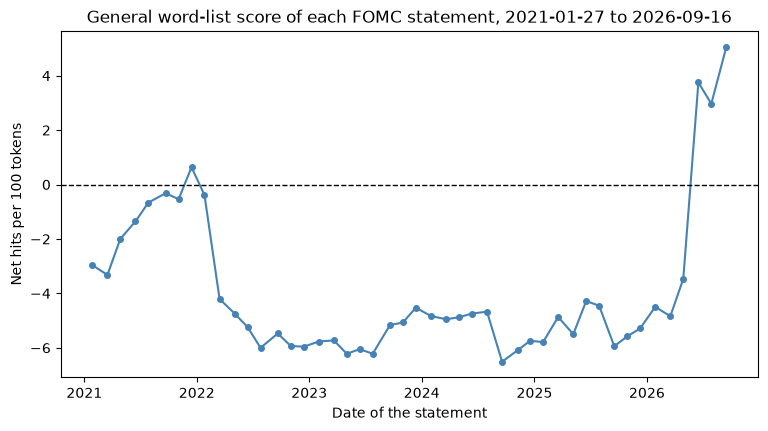

          date  general
7   2021-12-15     0.64
8   2022-01-26    -0.38
9   2022-03-16    -4.21
42  2026-04-29    -3.47
43  2026-06-17     3.75


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# one point for each statement, joined by a line
ax.plot(statements['meeting'], statements['general'], marker='o', markersize=4, color='steelblue')

# the zero line: below it the negative list has more hits than the positive list
ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.set_title('General word-list score of each FOMC statement, 2021-01-27 to 2026-09-16')
ax.set_xlabel('Date of the statement')
ax.set_ylabel('Net hits per 100 tokens')

plt.show()

print(statements[['date', 'general']].round(2).iloc[[7, 8, 9, 42, 43]])

* The score is between -3.32 and 0.64 for the first nine statements. It falls from -0.38 on 2022-01-26 to -4.21 on 2022-03-16 and stays between -6.51 and -3.47 through 2026-04-29.
* It rises from -3.47 on 2026-04-29 to 3.75 on 2026-06-17. The last three points are the three short statements.
* The chart shows that the score moved. It does not show why. Section 3.0 opens the score up to see which words are behind it.

**Excel side by side.** The sheet is called `statements`, with `date` in column A, `url` in column B, and `text` in column C, in rows 2 to 47. The 14 positive words are typed in F2:F15 and the 14 negative words in G2:G15. Excel has no token list, so each formula looks for a piece of text inside the cell, as `count()` did in notebook 17.

| Job | Python | Excel |
| --- | --- | --- |
| Statements that hold a piece of text | `statements['text'].str.lower().str.contains('restrictive').sum()` | `=COUNTIF(C2:C47, "*restrictive*")` |
| Times one piece of text appears in one statement | `text.lower().count('inflation')` | `=(LEN(C2) - LEN(SUBSTITUTE(LOWER(C2), "inflation", ""))) / LEN("inflation")` |
| Hits on a whole word list in one statement | a loop over the list, adding up `text.lower().count(word)` | `=SUMPRODUCT((LEN(C2) - LEN(SUBSTITUTE(LOWER(C2), $F$2:$F$15, ""))) / LEN($F$2:$F$15))` in D2 |
| The same for the negative list | | `=SUMPRODUCT((LEN(C2) - LEN(SUBSTITUTE(LOWER(C2), $G$2:$G$15, ""))) / LEN($G$2:$G$15))` in E2 |
| Net per 100 words | `(plus - minus) / words * 100` | `=(D2 - E2) / H2 * 100`, with the word count in H2 |

In `COUNTIF`, the `*` on each side stands for any characters, so the formula counts the cells that hold the letters anywhere, and it ignores capitals. `SUMPRODUCT` runs the count from notebook 17 once for each word of the list and adds the results. The next cell works out in Python what these formulas return, so that the two can be put side by side.

Q. What do the Excel formulas return for the first statement, and do they agree with the token count?

In [9]:
first_text = statements['text'].iloc[0].lower()

# COUNTIF with wildcards: the statements that hold the letters anywhere
print('Statements that hold restrictive:', statements['text'].str.lower().str.contains('restrictive').sum())

# the SUMPRODUCT formulas: count each word as a piece of text and add up
pieces_positive = sum([first_text.count(word) for word in positive_words])
pieces_negative = sum([first_text.count(word) for word in negative_words])
print('Pieces of text, positive list:', pieces_positive, ' negative list:', pieces_negative)
print('Whole tokens,   positive list:', n_positive, ' negative list:', n_negative)

# which words differ between the two ways of counting
for word in positive_words + negative_words:
    if first_text.count(word) != first_tokens.count(word):
        print(word, '- as a piece of text:', first_text.count(word), ' as a token:', first_tokens.count(word))

# all the words of the statement, the Excel word count of notebook 17
print('Words by split():', len(statements['text'].iloc[0].split()), ' kept tokens:', len(first_tokens))

Statements that hold restrictive: 4
Pieces of text, positive list: 6  negative list: 17
Whole tokens,   positive list: 5  negative list: 14
support - as a piece of text: 3  as a token: 2
weak - as a piece of text: 2  as a token: 0
decline - as a piece of text: 1  as a token: 0
Words by split(): 485  kept tokens: 304


* `=COUNTIF(C2:C47, "*restrictive*")` returns 4: four statements hold the word.
* For the first statement the positive formula returns 6 and the negative formula 17, against 5 and 14 by tokens. The printout names the three words behind the gap: `support` is also found inside `supporting`, `weak` inside `weakness` and `weaker`, and `decline` inside `declines`.
* The Excel formulas and `count()` agree with each other exactly. Both count pieces of text. The token match counts whole words. Neither is the correct one: they are two definitions, and a score has to say which it uses. This notebook uses whole tokens.
* The statement has 485 words by `split()` and 304 kept tokens. Excel has no stopword list of its own, so a per-100 figure in the sheet would divide by 485 unless the stopwords are removed first, as in notebook 17.

For the chart in Excel, select the dates and the scores and choose Insert, Line.

**Observations: a score from scratch**

* The score is the hits on a positive list less the hits on a negative list, per 100 kept tokens. Two lists of 14 general words were typed by hand.
* The general list scores 42 of 46 statements below zero, with a mean of -3.88, a low of -6.51 on 2024-09-18, and a high of 5.06 on 2026-09-16.
* The three highest scores belong to the three shortest statements, of 79 to 101 tokens.

## 3.0 Where a word list goes wrong

### 3.1 Sentences, so that a number can be read

A score is checked by reading the text behind it, and a whole statement is too long to read for every number. A sentence is the right size. Notebook 17 split one paragraph into sentences with `split('. ')`. The same rough split is used here on every statement.

Q. Split every statement into sentences, and keep the date with each one.

In [10]:
rows = []
for i in range(len(statements)):
    date = statements['date'].iloc[i]
    # paragraphs are separated by a line break. Turn it into a space, then cut at each full stop and space.
    pieces = statements['text'].iloc[i].replace('\n', ' ').split('. ')
    for piece in pieces:
        rows.append({'date': date, 'sentence': piece})

# a table with one row for each piece
sentences = pd.DataFrame(rows)

# the kept tokens of each piece, with the functions from section 1.2
sentences['kept'] = sentences['sentence'].apply(clean).apply(remove_stop_words)

print('Pieces:', len(sentences))

# the pieces of one statement: the first three and the last four
one = sentences[sentences['date'] == '2024-03-20']
print('Pieces in the statement dated 2024-03-20:', len(one))
for piece in one['sentence'].head(3):
    print('  ', piece)
for piece in one['sentence'].tail(4):
    print('  ', piece)

Pieces: 1198
Pieces in the statement dated 2024-03-20: 27
   Recent indicators suggest that economic activity has been expanding at a solid pace
   Job gains have remained strong, and the unemployment rate has remained low
   Inflation has eased over the past year but remains elevated
   Jefferson; Adriana D
   Kugler; Loretta J
   Mester; and Christopher J
   Waller.


* 1,198 pieces from 46 statements. The split drops the full stop that it cuts at.
* The first three pieces of the statement dated 2024-03-20 are sentences. The last four are not. The final paragraph of a statement lists names with middle initials, and each initial ends in a full stop and a space, so the split cuts there too. That statement gives 27 pieces, and those from the list of names are fragments.
* The limit is known and it is left in. A fragment of a name holds no word from any list in this notebook, so it adds nothing to a count. It would matter for an average over sentences, and no such average is taken today.

Q. Write two small helpers: one that finds the sentences whose tokens include a word, and one that prints sentences with their dates.

In [11]:
def sentences_with(word):
    # the rows of the sentence table whose kept tokens include the word
    keep = [word in tokens for tokens in sentences['kept']]
    return sentences[keep]


def show(table, limit):
    # print the first rows of a sentence table, each with the date of its statement
    for i in table.index[:limit]:
        print(table.loc[i, 'date'], '|', table.loc[i, 'sentence'])


show(sentences_with('restrictive'), 4)

2022-11-02 | The Committee anticipates that ongoing increases in the target range will be appropriate in order to attain a stance of monetary policy that is sufficiently restrictive to return inflation to 2 percent over time
2022-12-14 | The Committee anticipates that ongoing increases in the target range will be appropriate in order to attain a stance of monetary policy that is sufficiently restrictive to return inflation to 2 percent over time
2023-02-01 | The Committee anticipates that ongoing increases in the target range will be appropriate in order to attain a stance of monetary policy that is sufficiently restrictive to return inflation to 2 percent over time
2023-03-22 | The Committee anticipates that some additional policy firming may be appropriate in order to attain a stance of monetary policy that is sufficiently restrictive to return inflation to 2 percent over time


* Four sentences hold the token `restrictive`, one in each of four statements, which agrees with the `COUNTIF` of section 2.2.
* Every quotation in this notebook is printed this way: from the file, unchanged, with its date.

### 3.2 Which words produce the score

Q. Across all 46 statements, how many hits does each listed word have?

In [12]:
# one Counter for each list, fed the hits of each statement in turn
positive_counts = Counter()
negative_counts = Counter()
for tokens in statements['kept']:
    positive_counts.update([token for token in tokens if token in positive_words])
    negative_counts.update([token for token in tokens if token in negative_words])

print('Positive:', positive_counts.most_common())
print('Negative:', negative_counts.most_common())

total_positive = sum(positive_counts.values())
total_negative = sum(negative_counts.values())
print('Positive hits:', total_positive, ' negative hits:', total_negative, ' all hits:', total_positive + total_negative)
print('Share of all hits that are the word inflation:',
      round(negative_counts['inflation'] / (total_positive + total_negative) * 100, 1), 'percent')
print('Listed words with no hit:',
      [word for word in positive_words + negative_words if positive_counts[word] + negative_counts[word] == 0])

Positive: [('support', 66), ('gains', 35), ('progress', 34), ('solid', 26), ('strong', 23), ('growth', 11), ('confidence', 6), ('better', 5), ('recovery', 4), ('improvement', 4), ('improved', 4)]
Negative: [('inflation', 324), ('risks', 121), ('pressures', 50), ('unemployment', 40), ('debt', 31), ('uncertain', 19), ('lower', 14), ('hardship', 11), ('restrictive', 4), ('weak', 3), ('decline', 3)]
Positive hits: 218  negative hits: 620  all hits: 838
Share of all hits that are the word inflation: 38.7 percent
Listed words with no hit: ['good', 'stable', 'benefit', 'bad', 'worse', 'loss']


* 218 positive hits and 620 negative hits, 838 in all.
* One word, `inflation`, has 324 of them, which is 38.7 percent of all hits and more than every positive hit put together. `risks` has 121.
* On the positive side `support` leads with 66.
* Six of the 28 listed words never appear: `good`, `stable`, `benefit`, `bad`, `worse`, and `loss`. The most obvious words of a general list do no work on this text.

Q. Read the sentences. Which sentence holding `inflation` is repeated most often?

In [13]:
# value_counts() counts how many times each sentence appears in the file
repeated = sentences_with('inflation')['sentence'].value_counts()

print('Sentences that hold the token inflation:', len(sentences_with('inflation')))
print('Most repeated, in', repeated.iloc[0], 'statements:')
print(repeated.index[0])
print('Next, in', repeated.iloc[1], 'statements:')
print(repeated.index[1])

Sentences that hold the token inflation: 253
Most repeated, in 43 statements:
The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run
Next, in 27 statements:
The Committee's assessments will take into account a wide range of information, including readings on labor market conditions, inflation pressures and inflation expectations, and financial and international developments


* The sentence printed first appears in 43 of the 46 statements, word for word. Each time, the general list counts one negative hit for it.
* Read it. The list cannot tell a word used as a technical term from a word used as bad news. It sees the letters.

Q. Print one sentence, with its date, for each of seven listed words that are ordinary technical terms in this text.

In [14]:
# seven words from the two general lists
domain_terms = ['inflation', 'risks', 'restrictive', 'unemployment', 'pressures', 'strong', 'support']

for word in domain_terms:
    found = sentences_with(word)
    print(word, '- in', len(found), 'sentences. The first:')
    show(found, 1)

inflation - in 253 sentences. The first:
2021-01-27 | Weaker demand and earlier declines in oil prices have been holding down consumer price inflation
risks - in 117 sentences. The first:
2021-01-27 | The ongoing public health crisis continues to weigh on economic activity, employment, and inflation, and poses considerable risks to the economic outlook
restrictive - in 4 sentences. The first:
2022-11-02 | The Committee anticipates that ongoing increases in the target range will be appropriate in order to attain a stance of monetary policy that is sufficiently restrictive to return inflation to 2 percent over time
unemployment - in 40 sentences. The first:
2021-12-15 | Job gains have been solid in recent months, and the unemployment rate has declined substantially
pressures - in 50 sentences. The first:
2021-01-27 | The Committee's assessments will take into account a wide range of information, including readings on public health, labor market conditions, inflation pressures and inflati

* Each of the seven is part of the working vocabulary of these statements. The sentence printed for `support` is cut short at `U.S`, which is the rough split of section 3.1 at work.
* A general list scores `unemployment` as a negative word in a sentence that reports the rate, whatever the sentence says about it. It scores `support` as a positive word wherever the phrase appears.
* This is the **domain vocabulary** problem. A word list carries the sense its words have in everyday text. In a specialised text the same words can be plain terms of the trade.

Q. How much of the score do those seven words account for?

In [15]:
# hits of the seven words, out of all hits
seven_hits = sum([positive_counts[word] + negative_counts[word] for word in domain_terms])
all_hits = total_positive + total_negative
print('Hits from the seven words:', seven_hits, 'of', all_hits, '=', round(seven_hits / all_hits * 100, 1), 'percent')

# the two lists with the seven words taken out
positive_rest = [word for word in positive_words if word not in domain_terms]
negative_rest = [word for word in negative_words if word not in domain_terms]


def rest_score(tokens):
    # the score from what is left of the two general lists
    return list_score(tokens, positive_rest, negative_rest)


statements['general_rest'] = statements['kept'].apply(rest_score)

print('With all 28 words    - mean:', round(statements['general'].mean(), 2),
      ' statements below zero:', (statements['general'] < 0).sum())
print('Without the seven    - mean:', round(statements['general_rest'].mean(), 2),
      ' statements below zero:', (statements['general_rest'] < 0).sum())
print(statements[['date', 'general', 'general_rest']].round(2).iloc[[0, 12, 25]])

Hits from the seven words: 628 of 838 = 74.9 percent
With all 28 words    - mean: -3.88  statements below zero: 42
Without the seven    - mean: 0.51  statements below zero: 14
          date  general  general_rest
0   2021-01-27    -2.96          0.66
12  2022-07-27    -6.00         -0.50
25  2024-03-20    -4.95          0.99


* The seven words produce 628 of the 838 hits, 74.9 percent. Three quarters of the score comes from seven words that are terms of the trade here.
* Take them out and the picture turns over. The mean goes from -3.88 to 0.51, and the number of statements scored below zero goes from 42 to 14.
* The statement dated 2022-07-27 is scored at -6.00 with all 28 words and at -0.50 without the seven. The text of the statement did not change. The list did.
* A lexicon score is a statement about a text **and a list**. Change the list and the number changes, with the text untouched.

### 3.3 Negation

**Predict 2**

The statement dated 2024-01-31 has a sentence that contains the word `not`. The sentence is cleaned and the stopwords are removed, as in section 1.2. Is `not` among the kept tokens?

> A) yes, cleaning keeps every word
>
> B) no

Decide, then run the cell.

In [16]:
# the sentences of that statement whose text holds the word not, with a space on each side
that_day = sentences[sentences['date'] == '2024-01-31']
with_not = that_day[that_day['sentence'].str.contains(' not ')]
show(with_not, 1)

tokens = with_not['kept'].iloc[0]
print('Kept tokens:', tokens)
print("Is 'not' a stopword?", 'not' in stop_words)
print('Positive hits:', [token for token in tokens if token in positive_words])
print('Negative hits:', [token for token in tokens if token in negative_words])

2024-01-31 | The Committee does not expect it will be appropriate to reduce the target range until it has gained greater confidence that inflation is moving sustainably toward 2 percent
Kept tokens: ['committee', 'expect', 'appropriate', 'reduce', 'target', 'range', 'gained', 'greater', 'confidence', 'inflation', 'moving', 'sustainably', 'toward', 'percent']
Is 'not' a stopword? True
Positive hits: ['confidence']
Negative hits: ['inflation']


* The answer is B. `not` is on nltk's stopword list, so it is removed before any word is matched.
* The sentence gives one positive hit, `confidence`, and one negative hit, `inflation`. The same two hits would be counted if the word `not` were taken out of the sentence, or moved.
* A count of words has no grammar. It does not know which word a `not` belongs to, or that it is there at all.

Q. Which other sentences in the file contain `not`?

In [17]:
# every piece whose text holds the word not, once each
all_not = sentences[sentences['sentence'].str.contains(' not ')].drop_duplicates('sentence')
print('Different sentences with the word not:', len(all_not))
show(all_not, 10)

# the hits of the general lists in the first of them
first_not = all_not['kept'].iloc[0]
print('Positive hits in the first:', [token for token in first_not if token in positive_words])
print('Negative hits in the first:', [token for token in first_not if token in negative_words])

Different sentences with the word not: 4
2021-07-28 | The sectors most adversely affected by the pandemic have shown improvement but have not fully recovered
2024-01-31 | The Committee does not expect it will be appropriate to reduce the target range until it has gained greater confidence that inflation is moving sustainably toward 2 percent
2025-07-30 | Absent and not voting was Adriana D
2026-04-29 | Logan, who supported maintaining the target range for the federal funds rate but did not support inclusion of an easing bias in the statement at this time.
Positive hits in the first: ['improvement']
Negative hits in the first: []


* Four different pieces in the whole file hold the word. In the first, dated 2021-07-28, the general list finds one positive hit, `improvement`, and no negative hit. The word `not` comes later in that sentence and is invisible to the list.
* Negation is rare in this file. In other kinds of text it is common, and a word count handles it no better there.

**Observations: where a word list goes wrong**

* Of 838 hits, 324 are the single word `inflation`, and seven technical terms account for 628, or 74.9 percent.
* Without those seven words the mean score moves from -3.88 to 0.51 and the count of statements below zero from 42 to 14. The score depends on the list as much as on the text.
* One sentence that holds `inflation` appears in 43 of the 46 statements and is counted as a negative hit each time.
* `not` is a stopword. It is removed before matching, so the score of a sentence is the same with or without it.

## 4.0 A published general lexicon: VADER

### 4.1 What it is

The two lists of section 2.0 were typed in a minute. A published lexicon is the same idea done with care: thousands of words, each with a rating, and rules for the words around them. One ships with `nltk`. It is called VADER.

What can be said about its origin, from its own documentation:

* nltk's documentation (https://www.nltk.org/api/nltk.sentiment.vader.html) asks users to cite: "Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. Eighth International Conference on Weblogs and Social Media (ICWSM-14). Ann Arbor, MI, June 2014."
* The authors' page (https://github.com/cjhutto/vaderSentiment) describes it as "a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media", and says "It is fully open-sourced under the [MIT License]".
* The same page says the ratings were given by human raters on a scale from -4 to 4.

Note the words "social media". The lexicon was built for a kind of text that is far from today's file. That is why it is a useful test.

Q. Download the lexicon, create the analyzer, and look up some words.

In [18]:
# the lexicon is a small file that nltk downloads once, like the stopword list
ready = nltk.download('vader_lexicon', quiet=True)
print('Lexicon ready:', ready)

from nltk.sentiment import SentimentIntensityAnalyzer

# the analyzer is an object, as in notebook 04: it holds the lexicon and has a method that scores text
analyzer = SentimentIntensityAnalyzer()

# lexicon is a dictionary: the key is a word and the value is its rating
print('Entries in the lexicon:', len(analyzer.lexicon))

for word in ['good', 'bad', 'strong', 'weak', 'support', 'risks', 'unemployment', 'inflation',
             'restrictive', 'securities', 'treasury', 'credit', 'debt']:
    # get() returns the second value when the key is not in the dictionary
    print(word, analyzer.lexicon.get(word, 'not in the lexicon'))

Lexicon ready: True
Entries in the lexicon: 7502
good 1.9
bad -2.5
strong 2.3
weak -1.9
support 1.7
risks -1.1
unemployment -1.9
inflation not in the lexicon
restrictive not in the lexicon
securities 1.2
treasury 0.8
credit 1.6
debt -1.5


* 7,502 entries, each with a rating. `good` is rated 1.9 and `bad` -2.5. `strong` is 2.3 and `weak` -1.9.
* `inflation` and `restrictive` are not in the lexicon, so the word behind 324 hits of our own list counts for nothing here. `risks` is rated -1.1 and `unemployment` -1.9.
* The domain vocabulary problem has not gone away. It has moved. VADER rates `securities` at 1.2, `treasury` at 0.8, `credit` at 1.6, and `debt` at -1.5. In these statements those four are names of instruments.

Q. Score one sentence.

In [19]:
# the second piece of the statement dated 2024-03-20
sentence = sentences[sentences['date'] == '2024-03-20']['sentence'].iloc[1]
print('2024-03-20 |', sentence)

# polarity_scores() returns a dictionary of four numbers
result = analyzer.polarity_scores(sentence)
print(result)
print('Compound:', result['compound'])

2024-03-20 | Job gains have remained strong, and the unemployment rate has remained low
{'neg': 0.267, 'neu': 0.428, 'pos': 0.305, 'compound': 0.1779}
Compound: 0.1779


* Four numbers. `neg`, `neu`, and `pos` are the shares of the text that VADER rates as negative, neutral, and positive, and they add up to 1.
* `compound` is the one-number summary. The authors' page says it is "computed by summing the valence scores of each word in the lexicon, adjusted according to the rules, and then normalized to be between -1 (most extreme negative) and +1 (most extreme positive)".
* VADER scores this sentence at 0.1779. From here on, "the VADER score" means the compound.

**Excel side by side.** A rated lexicon is a two-column table: the word and its rating. With the lexicon pasted into a sheet named `lexicon`, words in column A and ratings in column B, `=XLOOKUP("strong", lexicon!A:A, lexicon!B:B)` returns 2.3, as `analyzer.lexicon['strong']` does. `=XLOOKUP("inflation", lexicon!A:A, lexicon!B:B, 0)` returns 0, because the fourth argument is the value to return when the word is not found. The rules that adjust the ratings are code, and they are the part that a lookup does not do.

### 4.2 Raw text, not cleaned text

Our own score needed cleaned tokens. VADER is different. Its rules use the things that cleaning throws away. The authors' page lists them: negations, punctuation, words in capitals, and words that strengthen or weaken the word after them. nltk's code also has a rule for the word `but`.

**Predict 3**

The cell below scores one sentence twice: once as published, and once after cleaning and stopword removal, with the kept tokens joined by spaces. Will the two compound scores be equal?

> A) yes, the rated words are the same in both
>
> B) no

Decide, then run the cell.

In [20]:
def vader_score(text):
    # the compound score of a text
    return analyzer.polarity_scores(text)['compound']


# the first sentence in the file that holds the word not
row = all_not.iloc[0]
raw_sentence = row['sentence']
cleaned_sentence = ' '.join(row['kept'])

print(row['date'], '|', raw_sentence)
print('Cleaned:', cleaned_sentence)
print('Compound, raw text:    ', vader_score(raw_sentence))
print('Compound, cleaned text:', vader_score(cleaned_sentence))

# the words that the cleaning removed and that VADER's rules look for
print("Is 'not' a stopword?", 'not' in stop_words, "  Is 'but' a stopword?", 'but' in stop_words)

2021-07-28 | The sectors most adversely affected by the pandemic have shown improvement but have not fully recovered
Cleaned: sectors adversely affected pandemic shown improvement fully recovered
Compound, raw text:     0.0037
Compound, cleaned text: 0.1531
Is 'not' a stopword? True   Is 'but' a stopword? True


* The answer is B. VADER scores the sentence as published at 0.0037 and the cleaned version at 0.1531.
* The rated words are the same in both. What changed is the words around them. `not` and `but` are stopwords, and the cleaning removed both. VADER's rules for negation and for `but` had nothing left to work on.
* Cleaning is not a step that is always right. It is right for a method that counts tokens, and it damages a method that reads the text as written. **Give each tool the input it was built for.**

Q. Score every statement both ways. How many scores change, and which changes most?

In [21]:
# the compound of each statement as published
statements['vader'] = statements['text'].apply(vader_score)

# and of the kept tokens joined by spaces
statements['vader_cleaned'] = statements['kept'].str.join(' ').apply(vader_score)

# the gap between the two
gap = (statements['vader_cleaned'] - statements['vader']).abs()

print('Statements whose score differs:', (gap > 0).sum(), 'of', len(statements))
print('Differs by more than 0.1:', (gap > 0.1).sum())
print('Largest gap:', round(gap.max(), 2))
print(statements.loc[gap.sort_values(ascending=False).index[:3], ['date', 'vader', 'vader_cleaned']])

Statements whose score differs: 41 of 46
Differs by more than 0.1: 8
Largest gap: 0.36
          date   vader  vader_cleaned
35  2025-06-18  0.8020         0.4404
16  2023-02-01 -0.7814        -0.4455
37  2025-09-17 -0.7992        -0.5574


* 41 of the 46 scores differ, and 8 differ by more than 0.1 on a scale that runs from -1 to 1.
* The largest gap is for the statement dated 2025-06-18: 0.802 on the text as published and 0.4404 on the cleaned text. For 2023-02-01 the two are -0.7814 and -0.4455. The largest gap is 0.36.
* The correct input is the raw text. The `vader` column holds those scores, and `vader_cleaned` is not used again in the lesson.

### 4.3 Every statement

Q. Draw the VADER score over time. How many statements are scored above 0.9, and how many below zero?

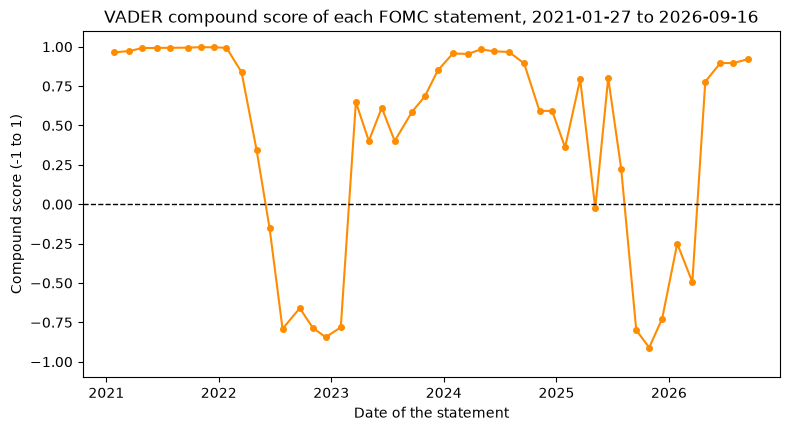

Scored above 0.9: 15
Scored below zero: 12
Lowest: 2025-10-29 -0.91
Highest: 2021-11-03 0.9975
The first nine: [0.9642, 0.9732, 0.9916, 0.9928, 0.9934, 0.9942, 0.9975, 0.9965, 0.9934]


In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(statements['meeting'], statements['vader'], marker='o', markersize=4, color='darkorange')
ax.axhline(0, color='black', linewidth=1, linestyle='--')

# the compound cannot leave the range -1 to 1
ax.set_ylim(-1.1, 1.1)
ax.set_title('VADER compound score of each FOMC statement, 2021-01-27 to 2026-09-16')
ax.set_xlabel('Date of the statement')
ax.set_ylabel('Compound score (-1 to 1)')

plt.show()

print('Scored above 0.9:', (statements['vader'] > 0.9).sum())
print('Scored below zero:', (statements['vader'] < 0).sum())
print('Lowest:', statements.loc[statements['vader'].idxmin(), 'date'], statements['vader'].min())
print('Highest:', statements.loc[statements['vader'].idxmax(), 'date'], statements['vader'].max())
print('The first nine:', statements['vader'].iloc[:9].round(4).tolist())

* VADER scores 15 of the 46 statements above 0.9 and 12 below zero. The lowest is -0.91 for the statement dated 2025-10-29 and the highest 0.9975 for 2021-11-03.
* The first nine statements are all scored between 0.96 and 1.00. The line is flat against the top of the chart there.
* That flatness is a property of the compound. A statement is several hundred words long and holds many rated words. Their sum is large, and the normalising step presses any large sum close to 1 or -1. The authors' page describes the compound as a measure for a given sentence. On a long text it tells little more than the sign.
* Our own score said 42 statements below zero. VADER says 12. Same text, different list, different answer.

### 4.4 Sentence by sentence

The compound is at home on a sentence. Scoring each sentence shows which ones drive a statement's score.

Q. Score every sentence. For the statement dated 2024-03-20, which sentences score highest and lowest?

In [23]:
# the compound of each piece of the sentence table
sentences['compound'] = sentences['sentence'].apply(vader_score)

print('Pieces scored exactly 0:', (sentences['compound'] == 0).sum(), 'of', len(sentences))

# the pieces of one statement, highest first, leaving out those scored 0
one = sentences[(sentences['date'] == '2024-03-20') & (sentences['compound'] != 0)]
one = one.sort_values('compound', ascending=False)
for i in one.index:
    print(one.loc[i, 'compound'], '|', one.loc[i, 'sentence'])

Pieces scored exactly 0: 670 of 1198
0.8126 | The Committee does not expect it will be appropriate to reduce the target range until it has gained greater confidence that inflation is moving sustainably toward 2 percent
0.4939 | The Committee is strongly committed to returning inflation to its 2 percent objective
0.4019 | In support of its goals, the Committee decided to maintain the target range for the federal funds rate at 5-1/4 to 5-1/2 percent
0.4019 | In addition, the Committee will continue reducing its holdings of Treasury securities and agency debt and agency mortgage-backed securities, as described in its previously announced plans
0.2023 | The Committee judges that the risks to achieving its employment and inflation goals are moving into better balance
0.1779 | Job gains have remained strong, and the unemployment rate has remained low
0.1531 | Inflation has eased over the past year but remains elevated
0.1531 | Recent indicators suggest that economic activity has been expandi

* 670 of the 1,198 pieces are scored exactly 0: they hold no rated word, or their rated words cancel. The fragments of names are among them.
* In the statement dated 2024-03-20, 12 pieces have a score other than 0. The highest is 0.8126, for the sentence of section 3.3 that holds the word `not`, and the lowest is -0.5106.
* Two pieces are scored 0.4019. One is about the target range and the other about holdings of securities. The next cell lists the rated words behind a score.

Q. Write a helper that lists the rated words of a text, and use it on the highest and the lowest sentence of that statement.

In [24]:
def rated_words(text):
    # the words of a text that are in VADER's lexicon, each with its rating
    words = re.findall(r'[a-z]+', text.lower())
    return [(word, analyzer.lexicon[word]) for word in words if word in analyzer.lexicon]


print(one['compound'].iloc[0], rated_words(one['sentence'].iloc[0]))
print(one['compound'].iloc[-1], rated_words(one['sentence'].iloc[-1]))
print(one['compound'].iloc[3], rated_words(one['sentence'].iloc[3]))

0.8126 [('gained', 1.6), ('greater', 1.5), ('confidence', 2.3)]
-0.5106 [('uncertain', -1.2), ('risks', -1.1)]
0.4019 [('treasury', 0.8), ('securities', 1.2), ('debt', -1.5), ('backed', 0.1), ('securities', 1.2)]


* The sentence scored 0.8126 has three rated words, `gained`, `greater`, and `confidence`, all above zero. VADER has a rule for `not`, and it reaches only the few words that follow it. The three rated words are further along.
* The sentence scored -0.5106 has two rated words, `uncertain` and `risks`.
* The third line is the sentence about holdings. Its rated words are `treasury`, `securities` twice, `debt`, and `backed`. They are names of instruments, rated as if they were everyday words.

Q. Across the whole file, which sentences does VADER score lowest and highest?

In [25]:
# each different sentence once, with the date of the first statement that holds it
unique = sentences.drop_duplicates('sentence').sort_values('compound')

print('Different pieces:', len(unique))
print('LOWEST')
for i in unique.index[:4]:
    print(unique.loc[i, 'date'], unique.loc[i, 'compound'], '|', unique.loc[i, 'sentence'])
    print('     rated words:', rated_words(unique.loc[i, 'sentence']))
print('HIGHEST')
for i in unique.index[-4:]:
    print(unique.loc[i, 'date'], unique.loc[i, 'compound'], '|', unique.loc[i, 'sentence'])
    print('     rated words:', rated_words(unique.loc[i, 'sentence']))

Different pieces: 312
LOWEST
2023-02-01 -0.8225 | Russia's war against Ukraine is causing tremendous human and economic hardship and is contributing to elevated global uncertainty
     rated words: [('war', -2.9), ('hardship', -1.3), ('uncertainty', -1.4)]
2021-04-28 -0.7351 | The ongoing public health crisis continues to weigh on the economy, and risks to the economic outlook remain
     rated words: [('crisis', -3.1), ('risks', -1.1)]
2022-07-27 -0.7351 | Russia's war against Ukraine is causing tremendous human and economic hardship
     rated words: [('war', -2.9), ('hardship', -1.3)]
2021-01-27 -0.7351 | The ongoing public health crisis continues to weigh on economic activity, employment, and inflation, and poses considerable risks to the economic outlook
     rated words: [('crisis', -3.1), ('risks', -1.1)]
HIGHEST
2021-07-28 0.8779 | Last December, the Committee indicated that it would continue to increase its holdings of Treasury securities by at least $80 billion per month and 

* 312 different pieces. The lowest score is -0.8225, for a sentence of the statement dated 2023-02-01. The highest is 0.891, for two sentences, in the statements dated 2021-04-28 and 2021-06-16.
* The rated words are printed under each sentence. In the lowest sentences they are everyday words with ratings well below zero, and there the lexicon is reading words in their everyday sense.
* In the highest sentences the list of rated words includes `progress`, `support`, `strong`, and, in the long sentences about holdings, `securities` and `treasury` again. The sentence scored 0.8779 has seven rated words, and four of them are `treasury`, `securities` twice, and `backed`.
* The scores at the two ends are produced by different kinds of word. A high score and a low score are not opposite ends of one measured thing.

**Observations: a published general lexicon**

* VADER ships with nltk. Its authors describe it as attuned to social media text, and it is under the MIT License.
* It takes raw text. On cleaned text 41 of 46 statement scores differ, by up to 0.36.
* On whole statements the compound sits near its limits: 15 statements above 0.9, with the first nine between 0.96 and 1.00. It scores 12 statements below zero, against 42 for our own general list.
* It does not hold `inflation`. It rates `securities`, `treasury`, `credit`, and `debt`, which are names of instruments in this text.

## 5.0 A word list built for this text

### 5.1 Candidates from the statements' own vocabulary

Both general lists stumbled on vocabulary. The third list is built the other way round: start from the words the statements use, and pick from them.

The list has two groups, described by what the words say and nothing more:

* **firm**: wording that describes activity as rising or firm, such as `solid` or `strong`,
* **soft**: wording that describes activity as falling or soft, such as `slowed` or `weak`.

Q. Count every kept token in the file, and look at the vocabulary.

In [26]:
# one Counter for the whole file, as in notebook 17
all_counts = Counter()
for tokens in statements['kept']:
    all_counts.update(tokens)

print('Different tokens:', len(all_counts))

# candidate words, typed after reading the full list of 507. A word that is absent prints 0.
candidates = ['expanding', 'expand', 'expanded', 'solid', 'strong', 'robust', 'strengthened', 'picked',
              'resilient', 'gains', 'booming', 'slowed', 'moderated', 'declined', 'weak', 'weakness',
              'weaker', 'softened', 'contracted', 'slumped']
for word in candidates:
    print(word, all_counts[word])

Different tokens: 507
expanding 12
expand 11
expanded 2
solid 26
strong 23
robust 12
strengthened 2
picked 2
resilient 8
gains 35
booming 0
slowed 8
moderated 7
declined 5
weak 3
weakness 1
weaker 1
softened 1
contracted 0
slumped 0


* The file has 507 different tokens, few enough to read from top to bottom. `print(all_counts.most_common())` shows them all.
* Three of the candidates print 0: `booming`, `contracted`, and `slumped`. They are words one might expect, and these statements do not use them. A `Counter` returns 0 for a key it has never seen, which makes the check simple.
* Taking candidates from the file's own counts means every word on the final list occurs in the file.

Q. Fix the two groups, and count the hits of each word.

In [27]:
firm_words = ['expanding', 'expand', 'expanded', 'solid', 'strong', 'robust', 'strengthened',
              'picked', 'resilient', 'gains']
soft_words = ['slowed', 'moderated', 'declined', 'weak', 'weakness', 'weaker', 'softened']

print('Firm:')
for word in firm_words:
    print('  ', word, all_counts[word])
print('Soft:')
for word in soft_words:
    print('  ', word, all_counts[word])

firm_total = sum([all_counts[word] for word in firm_words])
soft_total = sum([all_counts[word] for word in soft_words])
print('Firm hits:', firm_total, ' soft hits:', soft_total)

Firm:
   expanding 12
   expand 11
   expanded 2
   solid 26
   strong 23
   robust 12
   strengthened 2
   picked 2
   resilient 8
   gains 35
Soft:
   slowed 8
   moderated 7
   declined 5
   weak 3
   weakness 1
   weaker 1
   softened 1
Firm hits: 133  soft hits: 26


* 10 firm words with 133 hits and 7 soft words with 26 hits. The most frequent are `gains` with 35, `solid` with 26, and `strong` with 23. `softened` appears once.
* `picked` is the first word of a two-word verb. A token list holds single words, so the verb is matched by its first word.
* **This is one teaching list among many possible ones.** Which words go on it, and which group they go in, is a judgement. Another analyst would choose differently, and the scores would differ. The list is printed in full so that anyone can see what was counted.
* Word lists built for financial text exist. The usual reference is the Loughran-McDonald Master Dictionary, at https://sraf.nd.edu/loughranmcdonald-master-dictionary/. It is not used here, and a later course in this series uses trained models in place of word lists.

### 5.2 The score

Q. Score every statement: firm hits less soft hits, per 100 tokens.

In [28]:
def domain_score(tokens):
    # the score from the list built for this text
    return list_score(tokens, firm_words, soft_words)


statements['domain'] = statements['kept'].apply(domain_score)

# the hits behind one score, for the statement dated 2023-12-13
row = statements[statements['date'] == '2023-12-13'].iloc[0]
print('Firm hits:', [token for token in row['kept'] if token in firm_words])
print('Soft hits:', [token for token in row['kept'] if token in soft_words])
print('Tokens:', row['n_kept'], ' score:', round(row['domain'], 2))

print('Mean:', round(statements['domain'].mean(), 2), ' statements below zero:', (statements['domain'] < 0).sum(),
      ' at zero:', (statements['domain'] == 0).sum())
print('Lowest:', statements.loc[statements['domain'].idxmin(), 'date'], round(statements['domain'].min(), 2))
print('Highest:', statements.loc[statements['domain'].idxmax(), 'date'], round(statements['domain'].max(), 2))

Firm hits: ['strong', 'gains', 'strong', 'resilient']
Soft hits: ['slowed', 'moderated']
Tokens: 221  score: 0.9
Mean: 1.3  statements below zero: 3  at zero: 3
Lowest: 2021-01-27 -0.99
Highest: 2026-09-16 7.59


* The statement dated 2023-12-13 has 4 firm hits and 2 soft hits on 221 tokens: a net of 2, which is 0.9 per 100 tokens.
* The domain list scores 3 statements below zero and 3 at exactly zero. The mean is 1.3.
* The lowest score is -0.99 for 2021-01-27 and the highest 7.59 for 2026-09-16.

Q. Draw it.

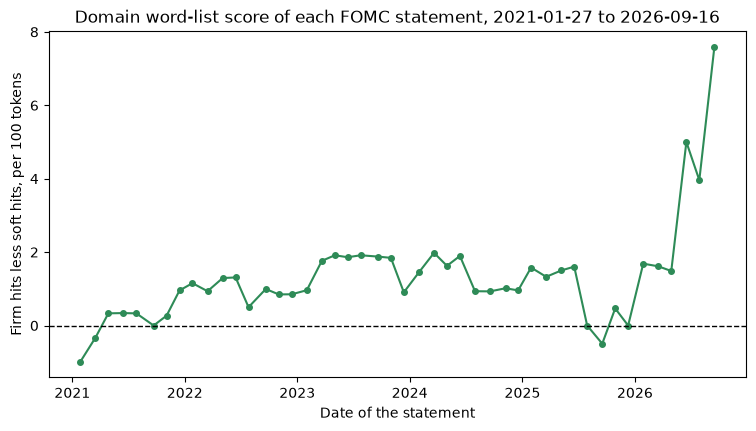

Highest score among the first 43 statements: 1.98
2026-04-29  tokens: 202  firm: 3  soft: 0  score: 1.49
2026-06-17  tokens: 80  firm: 4  soft: 0  score: 5.0
2026-07-29  tokens: 101  firm: 4  soft: 0  score: 3.96
2026-09-16  tokens: 79  firm: 6  soft: 0  score: 7.59


In [29]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(statements['meeting'], statements['domain'], marker='o', markersize=4, color='seagreen')
ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.set_title('Domain word-list score of each FOMC statement, 2021-01-27 to 2026-09-16')
ax.set_xlabel('Date of the statement')
ax.set_ylabel('Firm hits less soft hits, per 100 tokens')

plt.show()

print('Highest score among the first 43 statements:', round(statements['domain'].iloc[:43].max(), 2))

# the last four statements, with the counts behind each score
last_four = statements.iloc[-4:]
for i in last_four.index:
    tokens = last_four.loc[i, 'kept']
    print(last_four.loc[i, 'date'], ' tokens:', len(tokens),
          ' firm:', len([token for token in tokens if token in firm_words]),
          ' soft:', len([token for token in tokens if token in soft_words]),
          ' score:', round(last_four.loc[i, 'domain'], 2))

* For 43 statements the score is between -0.99 and 1.98. The last three are at 5.0, 3.96, and 7.59.
* Read the counts. The statement dated 2026-04-29 has 3 firm hits on 202 tokens. The statement dated 2026-06-17 has 4 firm hits on 80 tokens. One more hit, and a score more than three times as high, because the text is less than half as long.
* The score per 100 tokens rose from 1.49 to 5.0 between 2026-04-29 and 2026-06-17. Most of that rise is the denominator. A chart of the score alone would not show it. The counts do.

### 5.3 The same limits, on our own list

Q. Print every different sentence that holds the soft word `declined`.

In [30]:
found = sentences_with('declined').drop_duplicates('sentence')
print('Different sentences with declined:', len(found), ' hits in the file:', all_counts['declined'])
show(found, 10)

Different sentences with declined: 4  hits in the file: 5
2021-12-15 | Job gains have been solid in recent months, and the unemployment rate has declined substantially
2022-03-16 | Job gains have been strong in recent months, and the unemployment rate has declined substantially
2022-05-04 | Job gains have been robust in recent months, and the unemployment rate has declined substantially
2025-12-10 | The Committee judges that reserve balances have declined to ample levels and will initiate purchases of shorter-term Treasury securities as needed to maintain an ample supply of reserves on an ongoing basis


* `declined` has 5 hits in 4 different sentences. Read what the word describes in each. In none of the four is it economic activity: three are about a rate and one is about balances.
* The list counts each as a soft hit, because the list was told that `declined` is a soft word. Building the list from the file's vocabulary guarantees that the words occur. It does not guarantee that they are used in the sense the group's name claims.

**Predict 4**

`gains` is a firm word and `slowed` is a soft word. One sentence of the statement dated 2024-09-18 holds both, and no other word from the domain list. What does that sentence add to the net hits of its statement?

> A) -1
>
> B) 0
>
> C) +1

Decide, then run the cell.

In [31]:
# the sentences whose tokens hold both words
both = [('gains' in tokens) and ('slowed' in tokens) for tokens in sentences['kept']]
found = sentences[both]
print('Sentences with both gains and slowed:', len(found))

# the one in the statement dated 2024-09-18
found = found[found['date'] == '2024-09-18']
show(found, 1)

tokens = found['kept'].iloc[0]
print('Firm hits:', [token for token in tokens if token in firm_words])
print('Soft hits:', [token for token in tokens if token in soft_words])

# sentences with gains and the word low
both = [('gains' in tokens) and ('low' in tokens) for tokens in sentences['kept']]
show(sentences[both].tail(1), 1)

Sentences with both gains and slowed: 5
2024-09-18 | Job gains have slowed, and the unemployment rate has moved up but remains low
Firm hits: ['gains']
Soft hits: ['slowed']
2026-04-29 | Job gains have remained low, on average, and the unemployment rate has been little changed in recent months


* The answer is B. The sentence has one firm hit, `gains`, and one soft hit, `slowed`. They cancel, and the sentence adds 0.
* 5 sentences in the file hold both words. The list counts `gains` as a firm word each time, whatever the words after it say.
* The last sentence printed holds `gains` and `low`. `low` is on neither list, so the sentence adds one firm hit.
* None of this is fixed by choosing words more cleverly. A list of single words cannot see which word describes which.

**Excel side by side.** With the 10 firm words in J2:J11 and the 7 soft words in K2:K8, the formula from section 2.2 gives the net hits of the statement in row 2:

`=SUMPRODUCT((LEN(C2) - LEN(SUBSTITUTE(LOWER(C2), $J$2:$J$11, ""))) / LEN($J$2:$J$11)) - SUMPRODUCT((LEN(C2) - LEN(SUBSTITUTE(LOWER(C2), $K$2:$K$8, ""))) / LEN($K$2:$K$8))`

As before it counts pieces of text and not whole words. On this list that matters: `weak` is inside `weaker` and `weakness`, `expand` is inside `expanding` and `expanded`, `strong` is inside `strongly`, and `gains` is inside `against`.

**Observations: a word list built for this text**

* The domain list has 10 firm words with 133 hits and 7 soft words with 26 hits, all taken from the 507 different tokens of the file. It is one possible list, and the choice of words is a judgement.
* It scores 3 statements below zero, with a mean of 1.3. For 43 statements the score is between -0.99 and 1.98.
* The three highest scores, 3.96 to 7.59, belong to the three shortest statements, where 4 to 6 firm hits are divided by 79 to 101 tokens.
* `declined` is counted as soft in four sentences where it describes a rate or balances, and `gains` is counted as firm in sentences that also hold `slowed`.

## 6.0 Comparing the three scores

### 6.1 Side by side

Q. Put the three scores in one table, with the date as the row label. How are they distributed?

In [32]:
# set_index() makes the dates the row labels, as in notebook 14
scores = statements.set_index('meeting')[['general', 'vader', 'domain']]

print(scores.round(2).head(3))
print(scores.describe().round(2))

            general  vader  domain
meeting                           
2021-01-27    -2.96   0.96   -0.99
2021-03-17    -3.32   0.97   -0.33
2021-04-28    -1.99   0.99    0.33
       general  vader  domain
count    46.00  46.00   46.00
mean     -3.88   0.43    1.30
std       2.77   0.67    1.39
min      -6.51  -0.91   -0.99
25%      -5.74   0.04    0.59
50%      -4.85   0.73    1.08
75%      -3.36   0.96    1.67
max       5.06   1.00    7.59


* Three columns that claim to measure the same thing, on three different scales. `general` has a mean of -3.88 and runs from -6.51 to 5.06. `vader` has a mean of 0.43 and cannot leave the range -1 to 1. `domain` has a mean of 1.3 and runs from -0.99 to 7.59.
* For the first statement the three read -2.96, 0.96, and -0.99. Two below zero and one near the top of its range.

Q. How strongly are the three related? Work out the correlations.

In [33]:
# corr() gives the correlation of every pair of columns, as in notebook 11
print(scores.corr().round(2))

         general  vader  domain
general     1.00   0.48    0.51
vader       0.48   1.00    0.21
domain      0.51   0.21    1.00


* `general` with `vader`: 0.48. `general` with `domain`: 0.51. `vader` with `domain`: 0.21.
* A correlation of 1 would mean two scores rise and fall together exactly. These are well short of that. Three lists read the same 46 texts and agree only loosely.
* If the three were measuring one property of the text and measuring it well, they would agree. The size of the disagreement is a measure of how much of each score is the list.

### 6.2 One scale: z-scores

The three scores cannot share a chart as they are: one runs from -6.5 to 5 and another from -1 to 1. **Standardising** puts them on one scale. Subtract the column's mean from each value and divide by the column's standard deviation. The result is a **z-score**: how many standard deviations a value is above or below its own column's mean.

**Predict 5**

After standardising, what are the mean and the standard deviation of each column?

> A) the same as before, because the data has not changed
>
> B) a mean of 0 and a standard deviation of 1, in every column
>
> C) a mean of 0, and a standard deviation that differs by column

Decide, then run the cell.

In [34]:
# pandas subtracts each column's own mean and divides by its own standard deviation
z = (scores - scores.mean()) / scores.std()

print(z.describe().round(2).loc[['mean', 'std', 'min', 'max']])
print(z.round(2).head(3))

      general  vader  domain
mean     0.00  -0.00    0.00
std      1.00   1.00    1.00
min     -0.95  -2.01   -1.65
max      3.23   0.86    4.53
            general  vader  domain
meeting                           
2021-01-27     0.33   0.81   -1.65
2021-03-17     0.20   0.82   -1.18
2021-04-28     0.68   0.85   -0.70


* The answer is B. Every column now has a mean of 0 and a standard deviation of 1. The printed means show as 0.0 or -0.0, which is zero to within the rounding of the machine's arithmetic.
* Standardising changes the units and nothing else. The order of the values, the shape of each line, and every correlation are the same as before.
* The first statement reads 0.33, 0.81, and -1.65: above its column's mean on two lists and 1.65 standard deviations below it on the third.

Q. Draw the three z-scores on one chart.

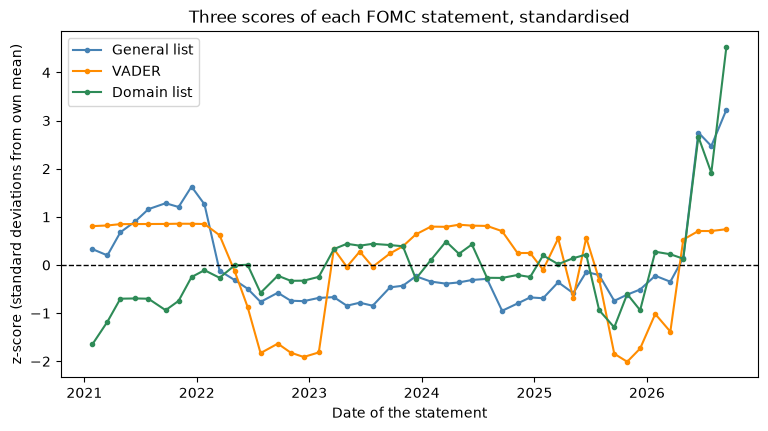

In [35]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(z.index, z['general'], marker='o', markersize=3, color='steelblue', label='General list')
ax.plot(z.index, z['vader'], marker='o', markersize=3, color='darkorange', label='VADER')
ax.plot(z.index, z['domain'], marker='o', markersize=3, color='seagreen', label='Domain list')

# zero is each score's own mean
ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.legend()
ax.set_title('Three scores of each FOMC statement, standardised')
ax.set_xlabel('Date of the statement')
ax.set_ylabel('z-score (standard deviations from own mean)')

plt.show()

* The three lines do not track each other. Through 2021 the general list and VADER are above their means and the domain list is below its mean.
* From mid 2022 to early 2023 VADER is the furthest below its mean, near -1.8, while the other two are within 1 of zero.
* At the right-hand edge the general and domain lines rise to between 1.9 and 4.5, on the three short statements, and VADER stays near 0.7.

Q. On which statements do the three disagree most, and least?

In [36]:
# for each statement, the gap between its highest and its lowest z-score
spread = z.max(axis=1) - z.min(axis=1)

print('Largest gaps:')
print(z[spread >= spread.sort_values().iloc[-3]].round(2))
print('Smallest gap:')
print(z[spread == spread.min()].round(2))
print('Mean gap:', round(spread.mean(), 2))

Largest gaps:
            general  vader  domain
meeting                           
2021-01-27     0.33   0.81   -1.65
2021-09-22     1.28   0.85   -0.94
2026-09-16     3.23   0.74    4.53
Smallest gap:
            general  vader  domain
meeting                           
2022-05-04    -0.31  -0.13   -0.01
Mean gap: 1.34


* The largest gap is on the statement dated 2026-09-16: 3.23 on the general list, 0.74 on VADER, and 4.53 on the domain list. Next are 2021-01-27, with 0.33, 0.81, and -1.65, and 2021-09-22, with 1.28, 0.85, and -0.94.
* The smallest gap is on 2022-05-04, where the three are -0.31, -0.13, and -0.01.
* The mean gap is 1.34 standard deviations. On an average statement, the highest and lowest of the three scores are more than one standard deviation apart.

**Excel side by side.** With the 46 general scores in D2:D47:

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| z-score of one value | `(scores - scores.mean()) / scores.std()` | `=STANDARDIZE(D2, AVERAGE($D$2:$D$47), STDEV.S($D$2:$D$47))` | 0.33 for 2021-01-27 |
| The same, written out | | `=(D2 - AVERAGE($D$2:$D$47)) / STDEV.S($D$2:$D$47)` | 0.33 |
| Correlation of two scores | `scores.corr()` | `=CORREL(D2:D47, E2:E47)`, with VADER in column E | 0.48 |

`STDEV.S` is the sample standard deviation, which is what `std()` in pandas returns. For the chart, select the dates and the three columns of z-scores and choose Insert, Line.

### 6.3 Change from one statement to the next

Q. How much did each score change from the statement before, and do the changes agree?

In [37]:
# diff() subtracts the row above from each row, as in notebook 14. The first row has no row above.
changes = scores.diff()

print(changes.round(2).head(3))
print('Rows with a change:', changes['general'].notna().sum())
print(changes.corr().round(2))

# the largest change in size, in each column
for column in ['general', 'vader', 'domain']:
    largest = changes[column].abs().idxmax()
    print(column, '- largest change:', round(changes.loc[largest, column], 2), 'on', largest.date())

# how often two scores moved in the same direction
same_direction = ((changes['general'] > 0) == (changes['domain'] > 0)) & changes['general'].notna()
print('General and domain moved the same way:', same_direction.sum(), 'of', changes['general'].notna().sum())

            general  vader  domain
meeting                           
2021-01-27      NaN    NaN     NaN
2021-03-17    -0.36   0.01    0.65
2021-04-28     1.33   0.02    0.66
Rows with a change: 45
         general  vader  domain
general     1.00   0.33    0.62
vader       0.33   1.00    0.20
domain      0.62   0.20    1.00
general - largest change: 7.22 on 2026-06-17
vader - largest change: 1.43 on 2023-03-22
domain - largest change: 3.63 on 2026-09-16
General and domain moved the same way: 21 of 45


* 45 changes from 46 statements. The first statement has no earlier one, so its change is `NaN`.
* The correlations of the changes are 0.33 for `general` with `vader`, 0.62 for `general` with `domain`, and 0.20 for `vader` with `domain`.
* The largest change in the general score is 7.22, between 2026-04-29 and 2026-06-17. In the domain score it is 3.63, between 2026-07-29 and 2026-09-16. Both are at the short statements. In VADER it is 1.43, between 2023-02-01 and 2023-03-22.
* The general and domain scores moved in the same direction in 21 of the 45 changes, fewer than half.

**Excel side by side.** A change is one subtraction filled down: `=D3 - D2` in row 3, with nothing in row 2. Then `=CORREL(F3:F47, G3:G47)` on two columns of changes.

**Observations: comparing the three scores**

* The correlations between the three scores are 0.48, 0.51, and 0.21. Between their changes they are 0.33, 0.62, and 0.20.
* On an average statement the highest and lowest z-scores are 1.34 standard deviations apart. On 2026-09-16 they are 3.79 apart.
* The general and domain scores moved the same way in 21 of 45 changes.
* Three lists, one text, three answers. No one of them is the score of a statement.

## 7.0 One cautious look outside the text

### 7.1 Yields on the statement dates

The desk head's last question is whether, on the statement dates, a change in a score has any relation in this file to the change in Treasury yields that day. The yields are the file from notebook 14. The answer will be a correlation and a chart, and then four cautions.

Q. Load the yields with the dates as row labels, and work out the daily change in the 2 Yr and 10 Yr yields in basis points.

In [38]:
# as in notebook 14: dates as dates, and as the row labels
yields = pd.read_csv(data_folder + 'treasury_par_yields.csv', parse_dates=['date'], index_col='date')
print('Rows:', len(yields), ' first date:', yields.index.min().date(), ' last date:', yields.index.max().date())

# diff() is the change from the previous row, which is the previous date Treasury published
# yields are in percent, and 1 percentage point is 100 basis points
yield_changes = (yields[['2 Yr', '10 Yr']].diff() * 100).round(0)
yield_changes.columns = ['chg_2yr_bp', 'chg_10yr_bp']

print(yield_changes.loc['2026-09-15':'2026-09-17'])

Rows: 2940  first date: 2015-01-02  last date: 2026-10-02
            chg_2yr_bp  chg_10yr_bp
date                               
2026-09-15         2.0          3.0
2026-09-16         7.0          1.0
2026-09-17        -7.0         -7.0


* 2,940 daily rows from 2015-01-02 to 2026-10-02.
* On 2026-09-16, the date of the last statement, the 2 Yr par yield was 7 basis points above the day before and the 10 Yr was 1 basis point above.
* `round(0)` is there because the yields are published to two decimal places, so a daily change is a whole number of basis points. The rounding removes the small errors of decimal arithmetic.

Q. Is every statement date in the yield file?

In [39]:
# isin() is True for each statement date that is a row label of the yields
in_yields = scores.index.isin(yield_changes.index)
print('Statement dates:', len(scores), ' found in the yield file:', in_yields.sum())
print('Not found:', list(scores.index[~in_yields].date))

Statement dates: 46  found in the yield file: 46
Not found: []


* All 46 statement dates have a row in the yield file, so nothing is missing.
* Had a date been missing, the honest course would be to leave its yield change as `NaN` and report the count. Filling it with a nearby day would compare the statement with the wrong day.

**Predict 6**

The 45 score changes are joined to the yield changes by date, with a left join that keeps every statement. How many rows have both a score change and a yield change?

> A) 46
>
> B) 45
>
> C) 2,940

Decide, then run the cell.

In [40]:
# join() lines the two tables up by their row labels. how='left' keeps every row of changes.
joined = changes.join(yield_changes, how='left')

print('Rows:', len(joined))
print('Rows with every value present:', len(joined.dropna()))
print(joined.round(2).head(3))
print(joined[['chg_2yr_bp', 'chg_10yr_bp']].describe().round(1).loc[['mean', 'std', 'min', 'max']])

Rows: 46
Rows with every value present: 45
            general  vader  domain  chg_2yr_bp  chg_10yr_bp
meeting                                                    
2021-01-27      NaN    NaN     NaN         1.0         -1.0
2021-03-17    -0.36   0.01    0.65        -2.0          1.0
2021-04-28     1.33   0.02    0.66         0.0          0.0
      chg_2yr_bp  chg_10yr_bp
mean        -1.2         -1.5
std          9.2          6.4
min        -27.0        -16.0
max         15.0         10.0


* The answer is B. The join has 46 rows, one for each statement, and 45 of them are complete. The first statement has a yield change and no score change.
* `join()` is new. It is `pd.merge()` for two tables that share their row labels: here both are labelled by date, so no `on=` is needed.
* On the 46 statement dates the daily change in the 2 Yr yield ran from -27 to 15 basis points and in the 10 Yr yield from -16 to 10.

**Excel side by side.** With the yield file on a sheet named `yields`, dates in column A, the `2 Yr` yield in column I, and the data in rows 2 to 2941:

| Job | pandas | Excel |
| --- | --- | --- |
| Daily change in basis points | `yields['2 Yr'].diff() * 100` | `=(I3 - I2) * 100` in P3 of the `yields` sheet, filled down |
| The change on a statement date | `changes.join(yield_changes, how='left')` | `=XLOOKUP(A2, yields!$A$2:$A$2941, yields!$P$2:$P$2941)` on the `statements` sheet |
| Correlation | `joined.corr()` | `=CORREL(F3:F47, H3:H47)`, with the score changes in column F and the looked-up yield changes in column H |

`XLOOKUP` returns `#N/A` for a date that is not on the `yields` sheet, which is Excel's version of the `NaN` a left join leaves.

### 7.2 The correlations

Q. What is the correlation between the change in each score and the change in each yield?

In [41]:
# corr() leaves out a row for a pair when one of its two values is missing
correlations = joined.corr().loc[['general', 'vader', 'domain'], ['chg_2yr_bp', 'chg_10yr_bp']]
print(correlations.round(2))
print('Points behind each figure:', len(joined.dropna()))

         chg_2yr_bp  chg_10yr_bp
general        0.19         0.07
vader         -0.06        -0.03
domain         0.27         0.16
Points behind each figure: 45


* With the 2 Yr change, the correlations are 0.19 for the general score, -0.06 for VADER, and 0.27 for the domain score. With the 10 Yr change they are 0.07, -0.03, and 0.16.
* All six are between -0.06 and 0.27, on 45 points. The VADER figures are near zero. A correlation near zero is a result, and it is reported as one.

Q. Draw the change in the domain score against the change in the 2 Yr yield.

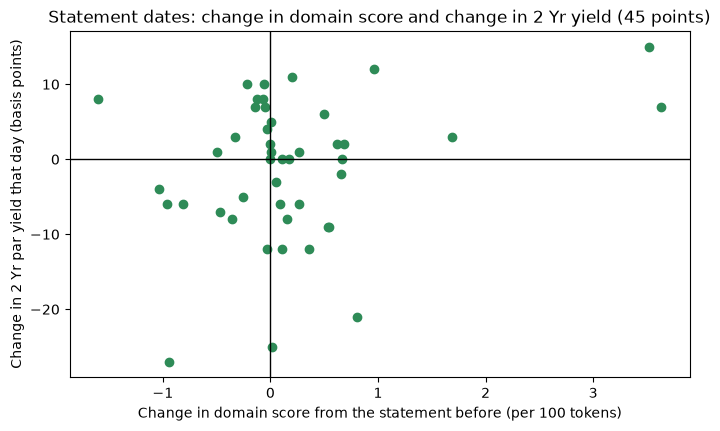

            domain  chg_2yr_bp
meeting                       
2026-09-16    3.63         7.0
2026-06-17    3.51        15.0
2026-01-28    1.69         3.0
Furthest left: -1.6


In [42]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# one point for each of the 45 changes
ax.scatter(joined['domain'], joined['chg_2yr_bp'], color='seagreen')

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.set_title('Statement dates: change in domain score and change in 2 Yr yield (45 points)')
ax.set_xlabel('Change in domain score from the statement before (per 100 tokens)')
ax.set_ylabel('Change in 2 Yr par yield that day (basis points)')

plt.show()

# the points furthest to the right, and the one furthest to the left
print(joined.sort_values('domain', ascending=False)[['domain', 'chg_2yr_bp']].round(2).head(3))
print('Furthest left:', round(joined['domain'].min(), 2))

* 43 of the 45 points are in a cloud between -1.6 and 1.69 on the horizontal axis, with no visible slope.
* Two points are far to the right, at 3.51 and 3.63. They are the changes into two of the three short statements, with yield changes of 15 and 7 basis points.

Q. What are the correlations without the last three statements?

In [43]:
# iloc[:-3] leaves out the last three rows
without_last = joined.iloc[:-3]
print('Points:', len(without_last.dropna()))
print(without_last.corr().loc[['general', 'vader', 'domain'], ['chg_2yr_bp', 'chg_10yr_bp']].round(2))

Points: 42
         chg_2yr_bp  chg_10yr_bp
general       -0.07        -0.11
vader         -0.07        -0.04
domain         0.07         0.10


* On the other 42 points, the correlations with the 2 Yr change are -0.07, -0.07, and 0.07, and with the 10 Yr change -0.11, -0.04, and 0.10. All six are within 0.11 of zero.
* The 0.27 and 0.19 of the full table rested on the three short statements, whose scores are high because their texts are short. Three points out of 45 carried the figure.

**What these numbers are, and are not**

* **A few dozen points.** 45 changes, or 42. A correlation on so few points moves a great deal when a handful are added or removed, as the last cell showed.
* **One of many things on those days.** The statement is one of many pieces of information that reach the market on a statement date. Nothing in this file separates one from another.
* **A par yield is an end-of-day figure.** The change used here is from one day's published yield to the next. It covers the whole day, and not the minutes around the publication of a statement.
* **A correlation in this file is a description of this file.** It says how two columns of 45 numbers line up. It is not a rule, it says nothing about a cause, and it says nothing about any other date.

The result, in one line: in this file, the change in each of the three scores and the same-day change in the 2 Yr and 10 Yr par yields have correlations between -0.06 and 0.27 on 45 points, and between -0.11 and 0.10 once the three shortest statements are left out. That is near zero. The notebook stops there.

**Observations: one cautious look outside the text**

* All 46 statement dates are in the yield file, and 45 have a score change to pair with a yield change.
* The six correlations are between -0.06 and 0.27. Without the three shortest statements they are between -0.11 and 0.10.
* These figures describe 45 pairs of numbers in two public files. They are not evidence about what moves yields.

## 8.0 Limits

**What a lexicon score is.** A count of chosen words, divided by a length. Every part of that is a choice: which words, which group each is in, what counts as a token, and what to divide by.

**What it is not.**

* It is not the meaning of a text. A word is counted the same whatever it describes: `declined` for a rate, `gains` beside `slowed`, `inflation` in a sentence repeated in 43 statements.
* It has no grammar. `not` was removed before matching by our own lists, and VADER's rule for it reaches only the few words after it.
* It is not independent of the list. The same 46 texts gave 42 statements below zero on one list, 12 on a second, and 3 on a third.
* It is not stable on short texts. The three shortest statements have the three highest scores on two of the three lists.
* It is not a measure of anything outside the text. Section 7.0 found correlations near zero with same-day yield changes, on 45 points.

A count of words can still be useful. It is fast, it is the same every time it is run, and every number can be traced to the words behind it. That last property is what the habits below protect.

## Summary

**The three scores**

| | General list | VADER | Domain list |
| --- | --- | --- | --- |
| What it counts | 14 positive and 14 negative everyday words, typed by hand | a published lexicon of 7,502 rated entries, with rules | 10 firm and 7 soft words taken from the file's vocabulary |
| Input | kept tokens | raw text | kept tokens |
| Scale | net hits per 100 tokens | compound, -1 to 1 | net hits per 100 tokens |
| Mean over 46 statements | -3.88 | 0.43 | 1.3 |
| Statements below zero | 42 | 12 | 3 |
| Lowest | -6.51 on 2024-09-18 | -0.91 on 2025-10-29 | -0.99 on 2021-01-27 |
| Highest | 5.06 on 2026-09-16 | 0.9975 on 2021-11-03 | 7.59 on 2026-09-16 |
| Main limit found | 628 of 838 hits come from seven technical terms | near its limits on long text, and rates names of instruments | counts a word whatever it describes |

**For the desk head**

1. **Can the wording be turned into a number?** Yes, in a few lines of code, and in more than one way. Three word lists gave three series for the same 46 statements from 2021-01-27 to 2026-09-16.
2. **Do the numbers agree?** Loosely. The correlations between the three are 0.48, 0.51, and 0.21, and on an average statement the highest and lowest are 1.34 standard deviations apart.
3. **What drives them?** The list, and the length of the text. One word, `inflation`, is 324 of the 838 hits of the general list. The three shortest statements, of 79 to 101 tokens, have the highest scores on two lists.
4. **Any relation to yields?** In this file, near zero. The correlations between score changes and same-day changes in the 2 Yr and 10 Yr par yields are between -0.06 and 0.27 on 45 points, and between -0.11 and 0.10 without the three shortest statements.
5. **How far can such a number be trusted?** As a count of stated words, fully: it can be checked by hand. As a reading of a statement, not at all without reading the sentences behind it.

**What was new today**

| Job | Code |
| --- | --- |
| Hits of a word list in a list of tokens | `[token for token in tokens if token in word_list]` |
| A score per 100 tokens | `(plus - minus) / len(tokens) * 100` |
| A published lexicon | `SentimentIntensityAnalyzer().polarity_scores(text)['compound']` |
| A rating in the lexicon | `analyzer.lexicon.get(word, 'not in the lexicon')` |
| z-scores | `(scores - scores.mean()) / scores.std()` |
| Join by date | `changes.join(yield_changes, how='left')` |

**The habits to keep**

* Print the words that hit. A score with no list of words behind it cannot be checked.
* Read the sentences behind a number, with their dates.
* Keep the count beside every average: the hits and the tokens, not only the hits per 100.
* Give each tool the input it was built for: tokens for a token count, raw text for VADER.
* Say which list produced a score, every time. "The general list scores the statement of 2024-09-18 at -6.51" is a fact. A score with no list named is not.
* Report a correlation with its number of points, and look at what happens when a few are left out.

Course 1 started with a single variable and ends with tables, charts, joins, and text from public files, each number checked against one you can work out by hand. The course project comes next: a holdings file and a set of questions, answered with everything from these eighteen notebooks.

## Exercises

The exercises use the same 46 statements and ask about statements, words, and cuts the lesson did not examine. Every answer is a count or a score from a stated list. None is a reading of what a statement means.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on, and print the words that hit. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, and defines `clean()`, `remove_stop_words()`, `list_score()`, and `vader_score()` as in the lesson. It creates `analyzer`, types the four word lists, and loads a fresh `statements` with the `kept` and `n_kept` columns. It prints (46, 6) and 10204.

In [44]:
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


def clean(text):
    # lower case, letters only, one space between words, then a list of tokens
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    return re.sub(r'\s+', ' ', text).strip().split(' ')


ready = nltk.download('stopwords', quiet=True)
ready = nltk.download('vader_lexicon', quiet=True)
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

stop_words = stopwords.words('english')
analyzer = SentimentIntensityAnalyzer()


def remove_stop_words(tokens):
    return [token for token in tokens if token not in stop_words]


def list_score(tokens, plus_words, minus_words):
    # hits on the plus list less hits on the minus list, per 100 tokens
    plus = len([token for token in tokens if token in plus_words])
    minus = len([token for token in tokens if token in minus_words])
    return (plus - minus) / len(tokens) * 100


def vader_score(text):
    return analyzer.polarity_scores(text)['compound']


# the three word lists of the lesson
positive_words = ['good', 'strong', 'better', 'gains', 'support', 'progress', 'improved',
                  'improvement', 'confidence', 'growth', 'solid', 'stable', 'recovery', 'benefit']
negative_words = ['bad', 'weak', 'worse', 'risks', 'inflation', 'unemployment', 'pressures',
                  'restrictive', 'uncertain', 'hardship', 'decline', 'loss', 'debt', 'lower']
firm_words = ['expanding', 'expand', 'expanded', 'solid', 'strong', 'robust', 'strengthened',
              'picked', 'resilient', 'gains']
soft_words = ['slowed', 'moderated', 'declined', 'weak', 'weakness', 'weaker', 'softened']

# a fresh copy of the statements. In Colab the file is read from GitHub.
if os.path.exists('../../../data/fomc_statements.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

statements = pd.read_csv(data_folder + 'fomc_statements.csv')
statements['meeting'] = pd.to_datetime(statements['date'], format='%Y-%m-%d')
statements['kept'] = statements['text'].apply(clean).apply(remove_stop_words)
statements['n_kept'] = statements['kept'].str.len()

print(statements.shape, statements['n_kept'].sum())

(46, 6) 10204


### Exercise 1

Q. For the statement dated 2024-03-20, print the tokens that hit the positive list and the tokens that hit the negative list. Store the number of negative hits in **ex1_negative** and the general score per 100 tokens, rounded to 2 decimal places, in **ex1_score**.

In [45]:
ex1_negative = ...
ex1_score = ...

In [46]:
check('Exercise 1 negative hits', ex1_negative, 16)
check('Exercise 1 score', ex1_score, -4.95)

Exercise 1 negative hits: not attempted yet
Exercise 1 score: not attempted yet


### Exercise 2

Q. Take the one word `inflation` off the negative list and score every statement again with the positive list and what is left. How many statements are scored below zero now? Store the answer in **ex2_below**. Which statement has the lowest score, and what is it, rounded to 2 decimal places? Store them in **ex2_date** and **ex2_lowest**.

In [47]:
ex2_below = ...
ex2_date = ...
ex2_lowest = ...

In [48]:
check('Exercise 2 statements below zero', ex2_below, 34)
check('Exercise 2 date of the lowest', ex2_date, '2025-09-17')
check('Exercise 2 lowest score', ex2_lowest, -3.47)

Exercise 2 statements below zero: not attempted yet
Exercise 2 date of the lowest: not attempted yet
Exercise 2 lowest score: not attempted yet


### Exercise 3

Q. The lesson found that VADER's compound sits near its limits on a whole statement. Score only the **first paragraph** of each statement, on the raw text. The paragraphs are separated by `'\n'`. How many of the 46 first paragraphs are scored below zero? Store the answer in **ex3_below**. Which statement's first paragraph is scored lowest? Store its date in **ex3_date**. Print that paragraph.

In [49]:
ex3_below = ...
ex3_date = ...

In [50]:
check('Exercise 3 first paragraphs below zero', ex3_below, 15)
check('Exercise 3 date of the lowest', ex3_date, '2025-10-29')

Exercise 3 first paragraphs below zero: not attempted yet
Exercise 3 date of the lowest: not attempted yet


### Exercise 4

Q. Score every statement with the domain list, firm less soft per 100 tokens. Then ask how much of that score is the length of the text. What is the correlation between `n_kept` and the domain score, rounded to 2 decimal places? Store it in **ex4_corr**. Standardise `n_kept` and store the z-score of the shortest statement, rounded to 2 decimal places, in **ex4_z**. Draw the score against the number of tokens as a scatter plot.

In [51]:
ex4_corr = ...
ex4_z = ...

In [52]:
check('Exercise 4 correlation', ex4_corr, -0.75)
check('Exercise 4 z-score of the shortest', ex4_z, -2.57)

Exercise 4 correlation: not attempted yet
Exercise 4 z-score of the shortest: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for the VADER score of the statement dated 2025-06-18, and for the number of statements that VADER scores below zero. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. The lesson worked out both numbers in sections 4.2 and 4.3: 0.802 and 12. Then run the code. Does the answer agree with the lesson?

In [53]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# clean the text first, then score it
statements['cleaned'] = statements['kept'].str.join(' ')
statements['vader'] = statements['cleaned'].apply(vader_score)

ex5_score = round(statements.loc[statements['date'] == '2025-06-18', 'vader'].iloc[0], 4)
ex5_below = int((statements['vader'] < 0).sum())

print('VADER score of the statement dated 2025-06-18:', ex5_score)
print('Statements scored below zero:', ex5_below)

VADER score of the statement dated 2025-06-18: 0.4404
Statements scored below zero: 11


Q. Find the bug and fix the code in the cell above, so that **ex5_score** and **ex5_below** hold the right answers.

In [54]:
check('Exercise 5 score of 2025-06-18', ex5_score, 0.802)
check('Exercise 5 statements below zero', ex5_below, 12)

Exercise 5 score of 2025-06-18: not yet. You have 0.4404
Exercise 5 statements below zero: not yet. You have 11
